# System Architecture Benchmark

**Proving that RAG + Multi-agents boost answer precision over plain LLM.**

| Architecture | RAG | Agent prompts |
|---|:---:|:---:|
| LLM Only | ✗ | ✗ |
| LLM + RAG | ✓ | ✗ |
| LLM + Agents | ✗ | ✓ |
| LLM + RAG + Agents | ✓ | ✓ |

**Judge metrics:**

| Metric | Scale | Meaning |
|---|---|---|
| Correctness | 0–3 | Factual accuracy |
| Completeness | 0–2 | Covers all aspects |
| Clarity | 0–2 | Student-friendly explanation |
| **Composite** | **0–1** | **Weighted combination** |

> Composite = Correctness/3 × 0.50 + Completeness/2 × 0.30 + Clarity/2 × 0.20

In [1]:
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

_ensure('sentence-transformers', 'sentence_transformers')
_ensure('rank-bm25', 'rank_bm25')
_ensure('python-dotenv', 'dotenv')
_ensure('httpx')
print('Dependencies OK')

/Users/denisvisneveckii/Desktop/ai-tutor/ai tutor code/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencies OK


In [2]:
import os, sys, json, random, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
project_root = Path('.').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv()

from benchmark_system import (
    _Backend, _RAGRetriever, AnswerJudge,
    generate_test_questions, load_questions_from_file,
    evaluate_all, compute_metrics, compute_gains,
    ARCH_NAMES,
)
from benchmark_fallback import load_chunks

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLORS = {
    'LLM Only':            '#6c757d',
    'LLM + RAG':           '#2196F3',
    'LLM + Agents':        '#FF9800',
    'LLM + RAG + Agents':  '#4CAF50',
}
print('Imports OK')

Imports OK


## ⚙️ Configuration

Set `DISCIPLINE`, `LEVEL`, and `SAMPLES` before running.

- `LEVEL = 'all'` runs all 3 levels (3× more API calls).
- `QUESTIONS_FILE = ''` → auto-generate from corpus via LLM.
- Results cache to `system_bench_gen.json` + `system_bench_judge.json` — reruns are free.

In [3]:
DISCIPLINE      = 'math'    # ← your discipline slug
LEVEL           = 'beginner'  # beginner | intermediate | advanced | all
SAMPLES         = 20          # questions to auto-generate (ignored if QUESTIONS_FILE set)
TOP_K           = 5           # RAG chunks per query
SEED            = 42
QUESTIONS_FILE  = ''          # path to pre-written JSON, or '' to auto-generate

DISCIPLINES_DIR = os.getenv('DISCIPLINES_DIR', 'data/disciplines')

# ── Load corpus ────────────────────────────────────────────────────────────
print(f'Loading corpus: {DISCIPLINE!r} from {DISCIPLINES_DIR!r}')
all_chunks = load_chunks(DISCIPLINES_DIR, DISCIPLINE)
assert all_chunks, 'No chunks found! Check DISCIPLINES_DIR in .env'
print(f'Chunks: {len(all_chunks)}')

# ── Build retriever ────────────────────────────────────────────────────────
print('Building RAG retriever ...')
retriever = _RAGRetriever(all_chunks)
print(f'Retriever ready: dense={retriever._dense_vecs is not None}, bm25={retriever._bm25_index is not None}')

# ── LLM clients ───────────────────────────────────────────────────────────
backend = _Backend.from_env(cache_path='system_bench_gen.json')
judge   = AnswerJudge(_Backend.from_env(cache_path='system_bench_judge.json'))
print(f'Backend: {backend}')

Loading corpus: 'math' from 'data/disciplines'
Chunks: 539
Building RAG retriever ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8086.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Retriever ready: dense=True, bm25=True
Backend: _Backend(provider='openrouter#ollama', model='google/gemini-2.5-flash', cache=156)


## 📋 Test Questions

Auto-generated from corpus chunks (or loaded from file). Each question has:
- `question`: realistic student question in Russian
- `topic`: inferred from source PDF filename
- `reference`: ground-truth answer derived from the chunk text

In [4]:
if QUESTIONS_FILE:
    print(f'Loading questions from {QUESTIONS_FILE}')
    questions = load_questions_from_file(QUESTIONS_FILE)
else:
    print(f'Generating {SAMPLES} QA pairs from corpus...')
    questions = generate_test_questions(backend, all_chunks, n=SAMPLES, seed=SEED,
                                        discipline_label=DISCIPLINE)

print(f'\nQuestions ready: {len(questions)}')
df_q = pd.DataFrame(questions)[['question', 'topic', 'reference']]
display(df_q)

Generating 20 QA pairs from corpus...
  Generating question 1/20 from Математическая статистика.pdf... ok  (89 chars)
  Generating question 2/20 from Математическая статистика.pdf... ok  (45 chars)
  Generating question 3/20 from Теория вероятностей.pdf... skip (no question extracted)
  Generating question 4/20 from Математическая статистика.pdf... ok  (28 chars)
  Generating question 5/20 from Математическая статистика.pdf... ok  (91 chars)
  Generating question 6/20 from Математическая статистика.pdf... skip (no question extracted)
  Generating question 7/20 from Математическая статистика.pdf... ok  (138 chars)
  Generating question 8/20 from Математическая статистика.pdf... ok  (154 chars)
  Generating question 9/20 from Теория вероятностей.pdf... ok  (86 chars)
  Generating question 10/20 from Математическая статистика.pdf... ok  (70 chars)
  Generating question 11/20 from Математическая статистика.pdf... ok  (43 chars)
  Generating question 12/20 from Математическая статистика.p

,question,topic,reference
0,Какая аппроксимация используется для распредел...,Математическая статистика,При большом числе степеней свободы для вычисле...
1,Каково математическое ожидание оценки F*n(y)?,Математическая статистика,Математическое ожидание оценки F*n(y) равно F(...
2,Что такое критерий согласия?,Математическая статистика,"Критерий согласия — это критерий, упомянутый н..."
3,Как вычисляется условное математическое ожидан...,Математическая статистика,"Для дискретных случайных величин ξ и η, где ξ ..."
4,Можно ли построить точный доверительный интерв...,Математическая статистика,"Да, можно построить точный доверительный интер..."
5,Как можно вычислить математическое ожидание че...,Математическая статистика,Математическое ожидание четвертой степени случ...
6,Чему равно математическое ожидание и дисперсия...,Теория вероятностей,Математическое ожидание стандартного нормально...
7,Как определяется функция распределения k-й пор...,Математическая статистика,Функция распределения k-й порядковой статистик...
8,Как можно представить выборочную дисперсию?,Математическая статистика,Выборочную дисперсию можно представить в следу...
9,Как строятся эффективные оценки в любом классе...,Математическая статистика,Эффективные оценки в любом классе строятся с п...


## Experiment 1 — Architecture Comparison

Single run: all 4 architectures answer every question, LLM-as-Judge rates each answer.

This is the **core ablation** — shows the individual and combined contribution of RAG and agents.

In [7]:
_levels = ['beginner', 'intermediate', 'advanced'] if LEVEL == 'all' else [LEVEL]
_all_metrics = {}   # level -> metrics dict
_all_results = {}   # level -> results dict
_all_gains   = {}   # level -> gains dict

for _lv in _levels:
    print(f'\n', '='*55)
    print(f'Running level: {_lv.upper()}')
    print(f'='*55)
    _res = evaluate_all(
        questions, DISCIPLINE, _lv, retriever,
        backend, judge, top_k=TOP_K, verbose=False,
    )
    _all_results[_lv] = _res
    _all_metrics[_lv] = compute_metrics(_res)
    _all_gains[_lv]   = compute_gains(_all_metrics[_lv])

# Use primary level for Exp 1-6
_primary = _levels[0]
metrics  = _all_metrics[_primary]
results  = _all_results[_primary]
gains    = _all_gains[_primary]

df_metrics = pd.DataFrame(metrics).T
df_metrics.index.name = 'Architecture'
display(df_metrics.round(3))


Running level: BEGINNER

[Q01/17] Какая аппроксимация используется для распределения Hn при большом числ...
  [LLM Only                           ] composite=1.00    [LLM + RAG                          ] composite=1.00    [LLM + Agents                       ] composite=0.42    [LLM + RAG + Agents                 ] composite=0.42  

[Q02/17] Каково математическое ожидание оценки F*n(y)?...
  [LLM Only                           ] composite=1.00    [LLM + RAG                          ] composite=1.00    [LLM + Agents                       ] composite=0.00    [LLM + RAG + Agents                 ] composite=0.00  

[Q03/17] Что такое критерий согласия?...
  [LLM Only                           ] composite=1.00    [LLM + RAG                          ] composite=1.00    [LLM + Agents                       ] composite=0.42    [LLM + RAG + Agents                 ] composite=0.52  

[Q04/17] Как вычисляется условное математическое ожидание E(ξ | η) для дискретн...
  [LLM Only                    

,mean_correctness,mean_completeness,mean_clarity,mean_composite,pct_good,pct_excellent,n
Architecture,,,,,,,
LLM Only,1.765,1.294,1.353,0.624,0.471,0.412,17.0
LLM + RAG,2.824,1.882,1.941,0.947,0.941,0.941,17.0
LLM + Agents,0.176,0.176,0.294,0.085,0.000,0.000,17.0
LLM + RAG + Agents,0.471,0.353,0.647,0.196,0.059,0.000,17.0


In [ ]:
_metric_display = {
    'mean_correctness':  'Correctness\n(÷3, 0–1)',
    'mean_completeness': 'Completeness\n(÷2, 0–1)',
    'mean_clarity':      'Clarity\n(÷2, 0–1)',
    'mean_composite':    'Composite\n(0–1)',
    'pct_good':          'Good answers\n(≥0.60)',
    'pct_excellent':     'Excellent\n(≥0.80)',
}
_norm_metrics = {
    'mean_correctness':  [metrics[a]['mean_correctness']/3  for a in ARCH_NAMES],
    'mean_completeness': [metrics[a]['mean_completeness']/2 for a in ARCH_NAMES],
    'mean_clarity':      [metrics[a]['mean_clarity']/2      for a in ARCH_NAMES],
    'mean_composite':    [metrics[a]['mean_composite']       for a in ARCH_NAMES],
    'pct_good':          [metrics[a]['pct_good']             for a in ARCH_NAMES],
    'pct_excellent':     [metrics[a]['pct_excellent']        for a in ARCH_NAMES],
}

fig, axes = plt.subplots(1, 6, figsize=(22, 5), sharey=False)
fig.suptitle(
    f'Experiment 1 — Architecture Comparison  |  {DISCIPLINE} · level={_primary} · n={len(questions)}',
    fontsize=13, fontweight='bold'
)
for ax, (metric_key, label) in zip(axes, _metric_display.items()):
    vals  = _norm_metrics[metric_key]
    clrs  = [COLORS[a] for a in ARCH_NAMES]
    bars  = ax.bar(range(4), vals, color=clrs, edgecolor='white', linewidth=0.8, alpha=0.9)
    ax.set_xticks(range(4))
    ax.set_xticklabels([a.replace(' + ', '+\n') for a in ARCH_NAMES], fontsize=7.5, rotation=20, ha='right')
    ax.set_ylim(0, 1.12)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.025,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('sys_01_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_01_comparison.png')

In [ ]:
_raw_df = pd.DataFrame({
    a: {
        'Correctness (÷3)':  metrics[a]['mean_correctness']/3,
        'Completeness (÷2)': metrics[a]['mean_completeness']/2,
        'Clarity (÷2)':      metrics[a]['mean_clarity']/2,
        'Composite':         metrics[a]['mean_composite'],
        'Good (≥0.60)':      metrics[a]['pct_good'],
        'Excellent (≥0.80)': metrics[a]['pct_excellent'],
    }
    for a in ARCH_NAMES
}).T

fig, ax = plt.subplots(figsize=(12, max(4, len(ARCH_NAMES) + 1)))
sns.heatmap(_raw_df, annot=True, fmt='.2f', cmap='YlGn',
            ax=ax, linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Score (normalised to 0–1)'})
ax.set_title(f'Performance heatmap — {DISCIPLINE} · {_primary}', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('sys_02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_02_heatmap.png')

## Experiment 2 — Score Distributions

Box + strip plots of composite scores across all questions.  
A good architecture should have **high median** and **low variance** — consistently useful answers.

> Outliers (low scores) are the most interesting: which architecture fails on hard questions?

In [ ]:
_dist_data = []
for arch in ARCH_NAMES:
    for row in results[arch]:
        _dist_data.append({'Architecture': arch, 'Composite': row['composite']})
df_dist = pd.DataFrame(_dist_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=df_dist, x='Architecture', y='Composite',
               palette=COLORS, inner='box', ax=ax, alpha=0.75, cut=0)
sns.stripplot(data=df_dist, x='Architecture', y='Composite',
              palette=COLORS, ax=ax, size=5, jitter=True, alpha=0.6, zorder=5)
ax.axhline(0.60, color='#FF9800', linestyle='--', alpha=0.7, label='Good threshold (0.60)')
ax.axhline(0.80, color='#4CAF50', linestyle='--', alpha=0.7, label='Excellent threshold (0.80)')
ax.set_ylim(-0.05, 1.1)
ax.set_title(f'Experiment 2 — Composite Score Distribution  |  {DISCIPLINE} · {_primary}',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Composite Score (0–1)')
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('sys_03_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_03_distribution.png')

## Experiment 3 — Radar Chart (Multi-Dimension View)

Shows all three quality dimensions simultaneously.  
A perfect architecture fills the triangle completely.  
Look for which architecture is consistently strong vs. which trades off one dimension for another.

In [ ]:
_radar_metrics = ['Correctness', 'Completeness', 'Clarity']
_radar_vals = {
    a: [
        metrics[a]['mean_correctness']  / 3,
        metrics[a]['mean_completeness'] / 2,
        metrics[a]['mean_clarity']      / 2,
    ]
    for a in ARCH_NAMES
}

_angles = np.linspace(0, 2 * np.pi, len(_radar_metrics), endpoint=False).tolist()
_angles += _angles[:1]  # close the polygon

fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw={'polar': True})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(_angles[:-1])
ax.set_xticklabels(_radar_metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8)

for arch in ARCH_NAMES:
    vals = _radar_vals[arch] + _radar_vals[arch][:1]
    ax.plot(_angles, vals, 'o-', linewidth=2, color=COLORS[arch], label=arch)
    ax.fill(_angles, vals, alpha=0.08, color=COLORS[arch])

ax.set_title(f'Experiment 3 — Quality Radar  |  {DISCIPLINE} · {_primary}',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('sys_04_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_04_radar.png')

## Experiment 4 — Per-Question Heatmap

Architecture × Question composite score matrix.  
- **Green cell** = high-quality answer for that question  
- **Red cell** = failed answer  
- **Row patterns**: consistently good/bad architectures  
- **Column patterns**: consistently hard/easy questions

In [ ]:
_hmap = pd.DataFrame(
    {arch: [r['composite'] for r in results[arch]] for arch in ARCH_NAMES},
    index=[f'Q{i+1:02d}: {q["question"][:35]}...' for i, q in enumerate(questions)]
).T

fig_h = max(5, len(ARCH_NAMES) * 1.2 + 1)
fig_w = max(14, len(questions) * 0.65 + 3)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(_hmap, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.4, vmin=0, vmax=1,
            cbar_kws={'label': 'Composite (0–1)'})
ax.set_title(f'Experiment 4 — Per-Question Composite  |  {DISCIPLINE} · {_primary}',
             fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('sys_05_perquestion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_05_perquestion_heatmap.png')

## Experiment 5 — Marginal Gain Decomposition

Answers the core research question: **how much does each component add?**

| Component | Gain = | Formula |
|---|---|---|
| RAG alone | `LLM+RAG` − `LLM Only` | isolated retrieval value |
| Agents alone | `LLM+Agents` − `LLM Only` | isolated prompt engineering value |
| Combined | `LLM+RAG+Agents` − `LLM Only` | total improvement |
| Synergy | Combined − (RAG + Agents) | superadditive interaction |

**Positive synergy** means RAG and agents work *better together* than separately —
the agent knows how to use retrieved context more effectively than a naive injection.

In [ ]:
_gain_labels = {
    'rag_gain':   'RAG alone\n(LLM+RAG − LLM Only)',
    'agent_gain': 'Agents alone\n(LLM+Agents − LLM Only)',
    'full_gain':  'Combined\n(Full − LLM Only)',
    'synergy':    'Synergy\n(Full − RAG − Agents)',
}
_gain_colors = {
    'rag_gain':   '#2196F3',
    'agent_gain': '#FF9800',
    'full_gain':  '#4CAF50',
    'synergy':    '#9C27B0',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f'Experiment 5 — Marginal Gain Decomposition  |  {DISCIPLINE} · {_primary}',
    fontsize=13, fontweight='bold'
)

# ── Left: gain bars ────────────────────────────────────────────────────────
_gkeys = ['rag_gain', 'agent_gain', 'full_gain', 'synergy']
_gvals = [gains[k] for k in _gkeys]
_gclrs = [_gain_colors[k] for k in _gkeys]
bars = ax1.bar(_gain_labels.values(), _gvals, color=_gclrs, edgecolor='white', alpha=0.9)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Composite Score Gain over LLM Only', fontweight='bold')
ax1.set_ylabel('Δ Composite (0–1)')
ax1.yaxis.grid(True, alpha=0.3)
ax1.set_axisbelow(True)
for bar, val in zip(bars, _gvals):
    ypos = val + 0.003 if val >= 0 else val - 0.015
    ax1.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=10, fontweight='bold')

# ── Right: stacked bar showing how each arch reaches its score ─────────────
_base = gains['base']
_stack_data = {
    'LLM Only':           [_base, 0, 0, 0],
    'LLM + RAG':          [_base, gains['rag_gain'], 0, 0],
    'LLM + Agents':       [_base, 0, gains['agent_gain'], 0],
    'LLM + RAG + Agents': [_base, gains['rag_gain'], gains['agent_gain'], gains['synergy']],
}
_stack_labels = ['Base (LLM Only)', 'RAG gain', 'Agent gain', 'Synergy']
_stack_clrs   = ['#6c757d', '#2196F3', '#FF9800', '#9C27B0']
_x = np.arange(4)
_bottoms = np.zeros(4)
for si, (sl, sc) in enumerate(zip(_stack_labels, _stack_clrs)):
    _svals = [_stack_data[a][si] for a in ARCH_NAMES]
    ax2.bar(_x, _svals, bottom=_bottoms, label=sl, color=sc, alpha=0.85, edgecolor='white')
    _bottoms += np.array(_svals)
ax2.set_xticks(_x)
ax2.set_xticklabels([a.replace(' + ', '+\n') for a in ARCH_NAMES], fontsize=9)
ax2.set_title('Score Decomposition per Architecture', fontweight='bold')
ax2.set_ylabel('Composite Score')
ax2.legend(fontsize=9, loc='upper left')
ax2.yaxis.grid(True, alpha=0.3)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('sys_06_gain_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_06_gain_decomposition.png')

print(f'\n  Base (LLM Only):    {gains["base"]:.3f}')
print(f'  RAG gain:           {gains["rag_gain"]:+.3f}')
print(f'  Agent gain:         {gains["agent_gain"]:+.3f}')
print(f'  Combined gain:      {gains["full_gain"]:+.3f}')
print(f'  Synergy:            {gains["synergy"]:+.3f}  ',
      '(RAG + Agents work better together ✓)' if gains['synergy'] > 0 else '(subadditive)')

## Experiment 6 — Level Sensitivity

Does the architecture advantage hold across **beginner / intermediate / advanced** students?

- Displayed only when `LEVEL = 'all'`
- Shows if agent-level adaptation (LEVEL_GUIDANCE prompts) provides consistent gains

In [ ]:
if len(_levels) > 1:
    _lv_rows = []
    for lv, m in _all_metrics.items():
        for arch in ARCH_NAMES:
            _lv_rows.append({'Level': lv, 'Architecture': arch,
                             'Composite': m[arch]['mean_composite']})
    df_lv = pd.DataFrame(_lv_rows)

    fig, ax = plt.subplots(figsize=(12, 5))
    _lv_order = ['beginner', 'intermediate', 'advanced']
    _x = np.arange(len(_lv_order))
    _w = 0.18
    for i, arch in enumerate(ARCH_NAMES):
        _vals = [_all_metrics.get(lv, {}).get(arch, {}).get('mean_composite', 0) for lv in _lv_order]
        ax.bar(_x + i * _w - 0.27, _vals, _w * 0.9, color=COLORS[arch], label=arch, alpha=0.9)
    ax.set_xticks(_x)
    ax.set_xticklabels(_lv_order)
    ax.set_title(f'Experiment 6 — Composite by Level  |  {DISCIPLINE}', fontweight='bold')
    ax.set_ylabel('Mean Composite (0–1)')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig('sys_07_level_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: sys_07_level_sensitivity.png')
else:
    print('Set LEVEL = "all" and re-run to see level sensitivity analysis.')

## Experiment 7 — Example Answers (Qualitative)

Shows actual answers for a single question across all 4 architectures.  
This is the most convincing **human-readable proof** that the full system is superior.

Change `EXAMPLE_IDX` to inspect different questions.

In [ ]:
EXAMPLE_IDX = 0   # ← change to inspect a different question

_eq = questions[EXAMPLE_IDX]
print(f'Question: {_eq["question"]}')
print(f'Topic:    {_eq["topic"]}')
print(f'Reference (first 200 chars): {_eq.get("reference", "")[:200]}...')
print()

for arch in ARCH_NAMES:
    row = results[arch][EXAMPLE_IDX]
    print('─' * 70)
    print(f'[{arch}]')
    print(f'  Correctness={row["correctness"]}  '
          f'Completeness={row["completeness"]}  '
          f'Clarity={row["clarity"]}  '
          f'Composite={row["composite"]:.2f}')
    print()
    print(row['answer'][:600])
    print()

---

## Partition A — Fix 1: Lightweight Agent Prompt

**Why the original agent collapsed:** `_QA_SYSTEM_PROMPT` contains three cold-QA killers:

```
"закреплённый за одним конкретным учебным блоком"  ← agent thinks it's inside a lesson
"если данных нет — не выдумывай"                   ← triggers when context='' → refusal
"задай уточняющий вопрос вместо ответа"            ← produces non-answers, judge scores 0
```

**The fix — `_QA_SYSTEM_LIGHT`:** strips all in-session guardrails and keeps only the
*pedagogically useful* parts:
- Level-aware guidance (beginner / intermediate / advanced)
- Structured explanation style (key terms bold, concise, Socratic ending)
- Always answer — no refusal triggers

**What this experiment proves:** how much of the agent value comes from *prompt engineering*
(structure, level adaptation) vs. the *in-session context* it was deprived of.

In [8]:
from benchmark_system import (
    ARCH_NAMES_EXTENDED, compute_gains_extended,
    _answer_llm_agents_light,
)

COLORS_EXT = {
    **COLORS,
    'LLM + Agents (Light)':              '#9C27B0',
    'LLM + RAG + Agents (In-Session)':   '#00BCD4',
}

# Run only the light arch (original 4 are already in `results`)
_light_name = 'LLM + Agents (Light)'
_light_results = {_light_name: []}

print(f'Running {_light_name} on {len(questions)} questions...')
for _qi, _q in enumerate(questions, 1):
    _qu, _to = _q['question'], _q.get('topic', DISCIPLINE)
    _ans  = _answer_llm_agents_light(_qu, _to, _primary, backend)
    _scr  = judge.rate(_qu, _to, _ans, _q.get('reference', ''))
    _light_results[_light_name].append({'question': _qu, 'topic': _to, 'answer': _ans, **_scr})
    print(f'  Q{_qi:02d} composite={_scr["composite"]:.2f}', end='  ')
print()

# Merge with existing results for metric computation
_results_a = {**results, **_light_results}
_metrics_a = compute_metrics(_results_a)

print('\n=== Light Agent Metrics ===')
_lm = _metrics_a[_light_name]
print(f'  Composite:  {_lm["mean_composite"]:.3f}')
print(f'  Good%:      {_lm["pct_good"]*100:.0f}%')
print(f'  Excellent%: {_lm["pct_excellent"]*100:.0f}%')
print(f'  vs LLM Only:    {_lm["mean_composite"] - _metrics_a["LLM Only"]["mean_composite"]:+.3f}')
print(f'  vs LLM+Agents:  {_lm["mean_composite"] - _metrics_a["LLM + Agents"]["mean_composite"]:+.3f}  '
      '← how much restrictive prompt cost')

Running LLM + Agents (Light) on 17 questions...
  Q01 composite=0.68    Q02 composite=1.00    Q03 composite=0.52    Q04 composite=1.00    Q05 composite=0.20    Q06 composite=0.42    Q07 composite=1.00    Q08 composite=0.52    Q09 composite=0.52    Q10 composite=0.10    Q11 composite=0.10    Q12 composite=0.52    Q13 composite=0.68    Q14 composite=0.42    Q15 composite=1.00    Q16 composite=0.52    Q17 composite=0.10  

=== Light Agent Metrics ===
  Composite:  0.546
  Good%:      35%
  Excellent%: 24%
  vs LLM Only:    -0.077
  vs LLM+Agents:  +0.461  ← how much restrictive prompt cost


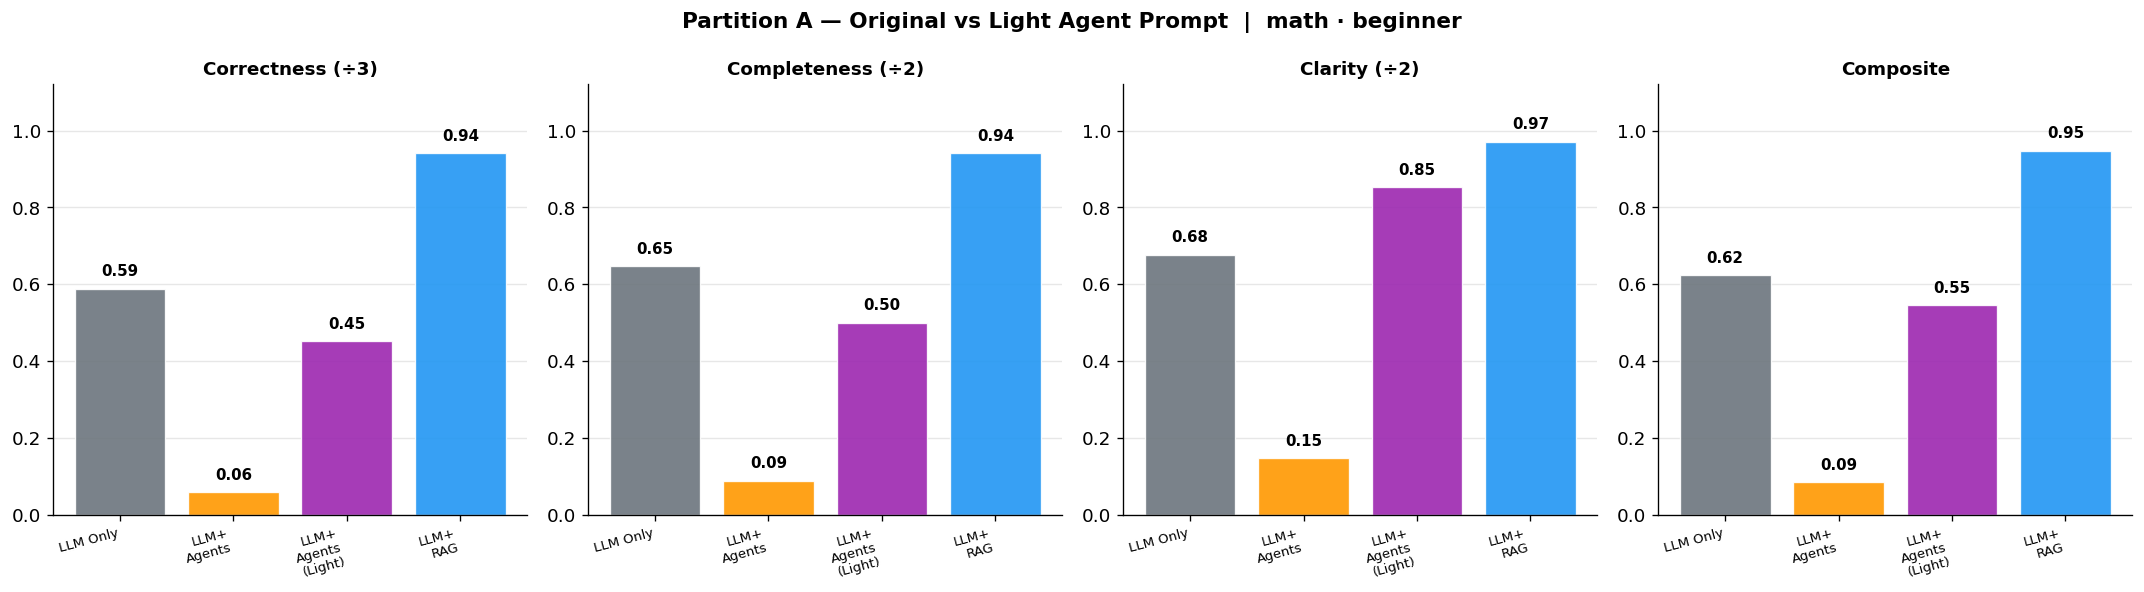

Saved: sys_08a_light_agent_comparison.png


In [9]:
# ── Side-by-side: Original agent vs Light agent vs LLM Only vs LLM+RAG ──────
_compare_archs = ['LLM Only', 'LLM + Agents', 'LLM + Agents (Light)', 'LLM + RAG']
_llm_metrics_a = ['mean_correctness', 'mean_completeness', 'mean_clarity', 'mean_composite']
_labels_a      = ['Correctness (÷3)', 'Completeness (÷2)', 'Clarity (÷2)', 'Composite']
_norm_a = {
    'mean_correctness':  lambda m: m/3,
    'mean_completeness': lambda m: m/2,
    'mean_clarity':      lambda m: m/2,
    'mean_composite':    lambda m: m,
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    f'Partition A — Original vs Light Agent Prompt  |  {DISCIPLINE} · {_primary}',
    fontsize=13, fontweight='bold'
)
for ax, mkey, mlabel in zip(axes, _llm_metrics_a, _labels_a):
    _vals  = [_norm_a[mkey](_metrics_a[a][mkey]) for a in _compare_archs]
    _clrs  = [COLORS_EXT.get(a, '#888') for a in _compare_archs]
    _xlabs = [a.replace(' + ', '+\n').replace(' (', '\n(') for a in _compare_archs]
    bars = ax.bar(range(len(_compare_archs)), _vals, color=_clrs,
                  edgecolor='white', linewidth=0.8, alpha=0.9)
    ax.set_xticks(range(len(_compare_archs)))
    ax.set_xticklabels(_xlabs, fontsize=8, rotation=15, ha='right')
    ax.set_ylim(0, 1.12)
    ax.set_title(mlabel, fontweight='bold', fontsize=11)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, _vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.025,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('sys_08a_light_agent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_08a_light_agent_comparison.png')

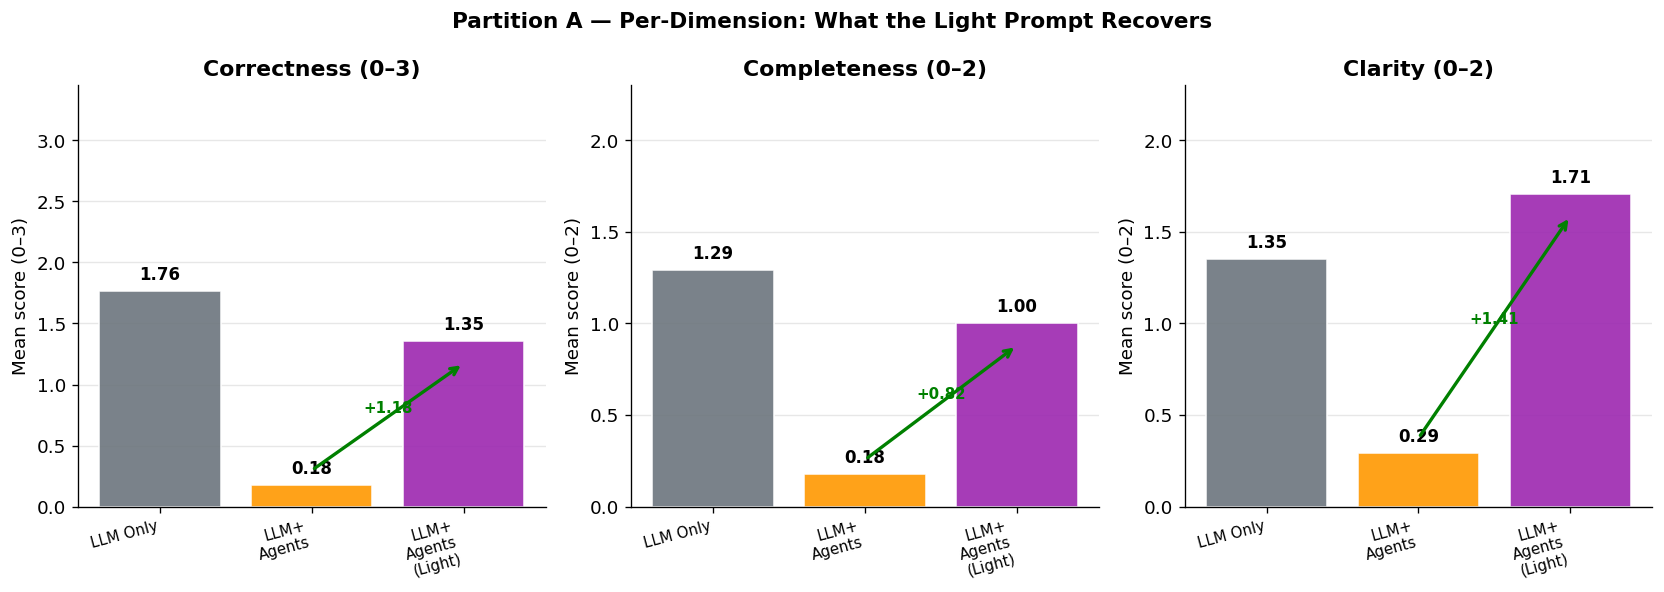

Saved: sys_08b_light_dimension_recovery.png


In [10]:
# ── Dimension breakdown: what each prompt change affects ──────────────────────
_dim_archs  = ['LLM Only', 'LLM + Agents', 'LLM + Agents (Light)']
_dim_keys   = ['mean_correctness', 'mean_completeness', 'mean_clarity']
_dim_labels = ['Correctness (0–3)', 'Completeness (0–2)', 'Clarity (0–2)']
_dim_maxs   = [3, 2, 2]   # raw scale maxima for display

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Partition A — Per-Dimension: What the Light Prompt Recovers',
             fontsize=13, fontweight='bold')
for ax, dkey, dlabel, dmax in zip(axes, _dim_keys, _dim_labels, _dim_maxs):
    _vals  = [_metrics_a[a][dkey] for a in _dim_archs]
    _clrs  = [COLORS_EXT.get(a, '#888') for a in _dim_archs]
    _xlabs = [a.replace(' + ', '+\n').replace(' (', '\n(') for a in _dim_archs]
    bars = ax.bar(range(3), _vals, color=_clrs, edgecolor='white', alpha=0.9)
    ax.set_xticks(range(3))
    ax.set_xticklabels(_xlabs, fontsize=9, rotation=15, ha='right')
    ax.set_ylim(0, dmax * 1.15)
    ax.set_title(dlabel, fontweight='bold')
    ax.set_ylabel(f'Mean score (0–{dmax})')
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, _vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + dmax*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Draw recovery arrow
    y0, y2 = _vals[1], _vals[2]
    if y2 > y0 + 0.05:
        ax.annotate('', xy=(2, y2 - dmax*0.06), xytext=(1, y0 + dmax*0.04),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))
        ax.text(1.5, (y0 + y2)/2, f'+{y2-y0:.2f}', ha='center', fontsize=9,
                color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('sys_08b_light_dimension_recovery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_08b_light_dimension_recovery.png')

---

## Partition B — Fix 2: In-Session Context Simulation

**Root cause of agent failure:** `qa_agent` is designed to answer questions *after* the student
already read a lesson block. It relies on `last_block_content` being set. Without it,
the agent declares it has no data and refuses.

**The fix — `_answer_llm_rag_agents_insession`:**

```
Step 1  →  Generate (or cache) a lesson block for the topic   [content_agent simulation]
Step 2  →  Retrieve additional RAG chunks for the question    [qa_agent runtime search]
Step 3  →  Full agent prompt with lesson + chunks as context  [production behavior]
```

This is the **architecturally correct** comparison — the agent now operates exactly as it does
in production, with the prerequisite in-session context that it was designed to use.

**Lesson blocks are cached** in `system_bench_gen.json` — the first run generates them once,
all subsequent reruns cost nothing.

In [11]:
from benchmark_system import (
    _generate_lesson_block, _answer_llm_rag_agents_insession,
)

_insession_name = 'LLM + RAG + Agents (In-Session)'
_insession_results = {_insession_name: []}
_lesson_cache = {}   # pre-generate lesson blocks once, reuse for every question

print(f'Running {_insession_name}...')
print('(First unique topic triggers lesson pre-generation — cached for reuse)')
print()
for _qi, _q in enumerate(questions, 1):
    _qu, _to = _q['question'], _q.get('topic', DISCIPLINE)
    _ans  = _answer_llm_rag_agents_insession(
        _qu, _to, _primary, retriever, DISCIPLINE, backend, TOP_K, _lesson_cache
    )
    _scr  = judge.rate(_qu, _to, _ans, _q.get('reference', ''))
    _insession_results[_insession_name].append(
        {'question': _qu, 'topic': _to, 'answer': _ans, **_scr}
    )
    print(f'  Q{_qi:02d} composite={_scr["composite"]:.2f}', end='  ')
print()

print(f'\nLesson blocks pre-generated: {len(_lesson_cache)} unique topics')

# Merge ALL 6 architectures for full comparison
_results_b = {**_results_a, **_insession_results}
_metrics_b = compute_metrics(_results_b)
_gains_b   = compute_gains_extended(_metrics_b)

print('\n=== In-Session Metrics ===')
_im = _metrics_b[_insession_name]
print(f'  Composite:       {_im["mean_composite"]:.3f}')
print(f'  Good%:           {_im["pct_good"]*100:.0f}%')
print(f'  vs LLM Only:     {_im["mean_composite"] - _metrics_b["LLM Only"]["mean_composite"]:+.3f}')
print(f'  vs LLM+RAG:      {_im["mean_composite"] - _metrics_b["LLM + RAG"]["mean_composite"]:+.3f}  '
      '← agent value on top of retrieval')
print(f'  vs RAG+Agents:   {_im["mean_composite"] - _metrics_b["LLM + RAG + Agents"]["mean_composite"]:+.3f}  '
      '← how much in-session context fixed it')

Running LLM + RAG + Agents (In-Session)...
(First unique topic triggers lesson pre-generation — cached for reuse)

    [pre-gen lesson for 'Математическая статистика'] ok
  Q01 composite=0.00    Q02 composite=0.00    Q03 composite=1.00    Q04 composite=0.00    Q05 composite=0.00    Q06 composite=0.00      [pre-gen lesson for 'Теория вероятностей'] ok
  Q07 composite=0.00    Q08 composite=0.00    Q09 composite=0.00    Q10 composite=0.00    Q11 composite=0.00    Q12 composite=0.00    Q13 composite=0.00    Q14 composite=0.00    Q15 composite=0.00    Q16 composite=0.00    Q17 composite=0.00  

Lesson blocks pre-generated: 2 unique topics

=== In-Session Metrics ===
  Composite:       0.059
  Good%:           6%
  vs LLM Only:     -0.565
  vs LLM+RAG:      -0.888  ← agent value on top of retrieval
  vs RAG+Agents:   -0.137  ← how much in-session context fixed it


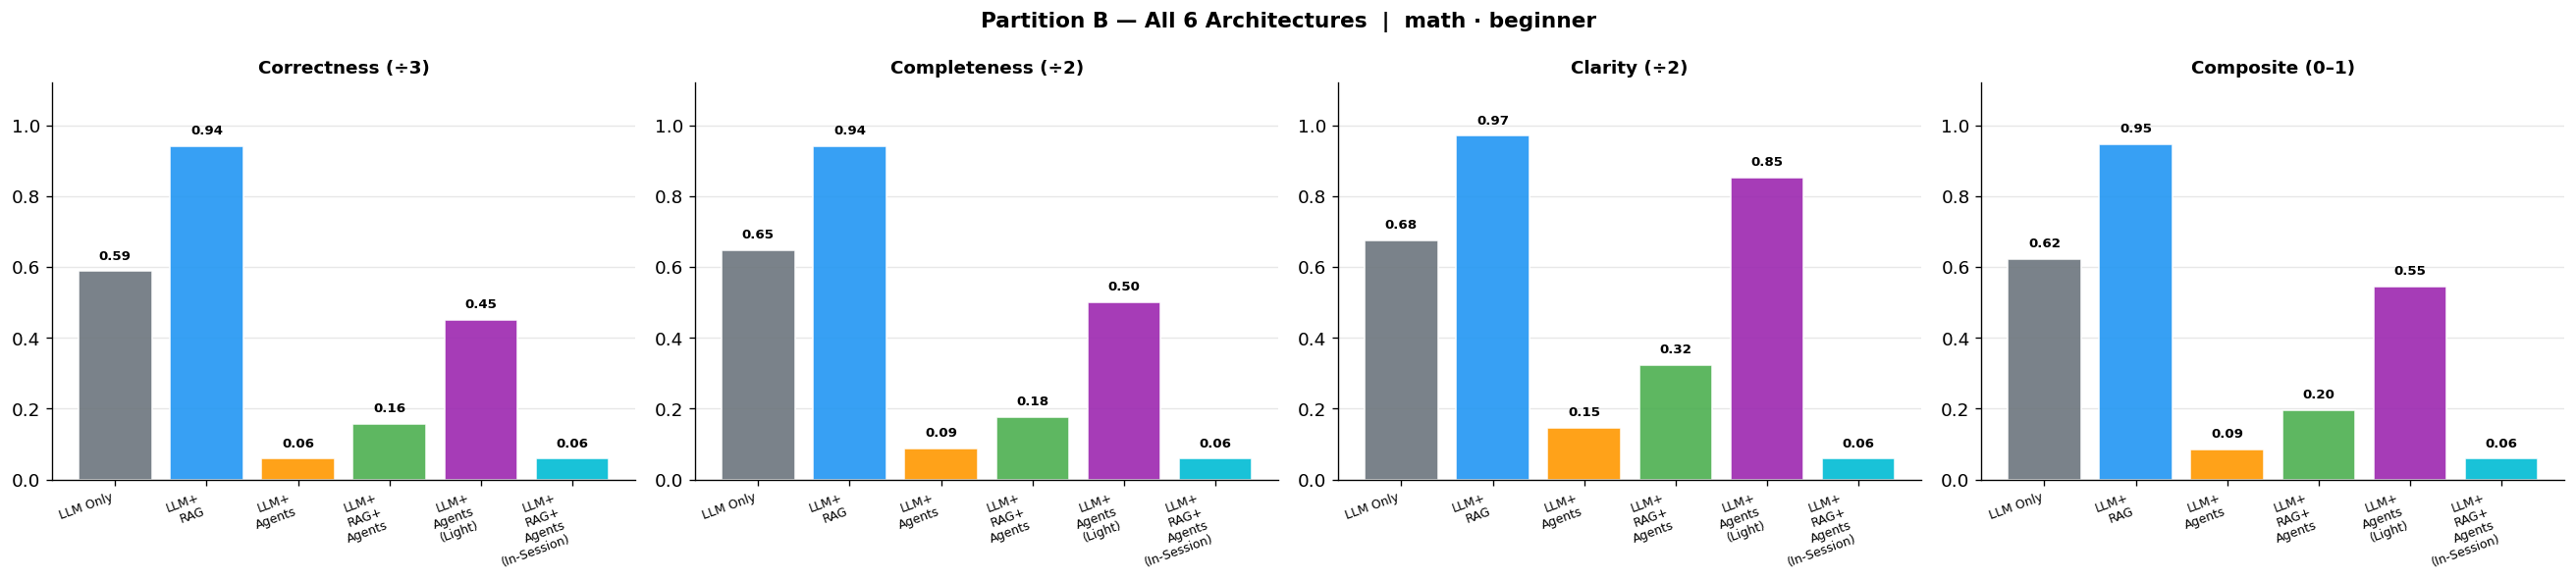

Saved: sys_09a_all6_comparison.png


In [12]:
# ── Full 6-architecture comparison ───────────────────────────────────────────
_all6 = list(ARCH_NAMES_EXTENDED)
_met6 = _metrics_b

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    f'Partition B — All 6 Architectures  |  {DISCIPLINE} · {_primary}',
    fontsize=13, fontweight='bold'
)
_mn6 = {
    'mean_correctness':  (lambda m: m/3, 'Correctness (÷3)'),
    'mean_completeness': (lambda m: m/2, 'Completeness (÷2)'),
    'mean_clarity':      (lambda m: m/2, 'Clarity (÷2)'),
    'mean_composite':    (lambda m: m,   'Composite (0–1)'),
}
for ax, (mkey, (norm_fn, mlabel)) in zip(axes, _mn6.items()):
    _vals  = [norm_fn(_met6[a][mkey]) for a in _all6 if a in _met6]
    _names = [a for a in _all6 if a in _met6]
    _clrs  = [COLORS_EXT.get(a, '#888') for a in _names]
    _xlabs = [a.replace(' + ', '+\n').replace(' (', '\n(') for a in _names]
    bars = ax.bar(range(len(_names)), _vals, color=_clrs, edgecolor='white', alpha=0.9)
    ax.set_xticks(range(len(_names)))
    ax.set_xticklabels(_xlabs, fontsize=7.5, rotation=20, ha='right')
    ax.set_ylim(0, 1.12)
    ax.set_title(mlabel, fontweight='bold', fontsize=11)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, _vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.025,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('sys_09a_all6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_09a_all6_comparison.png')

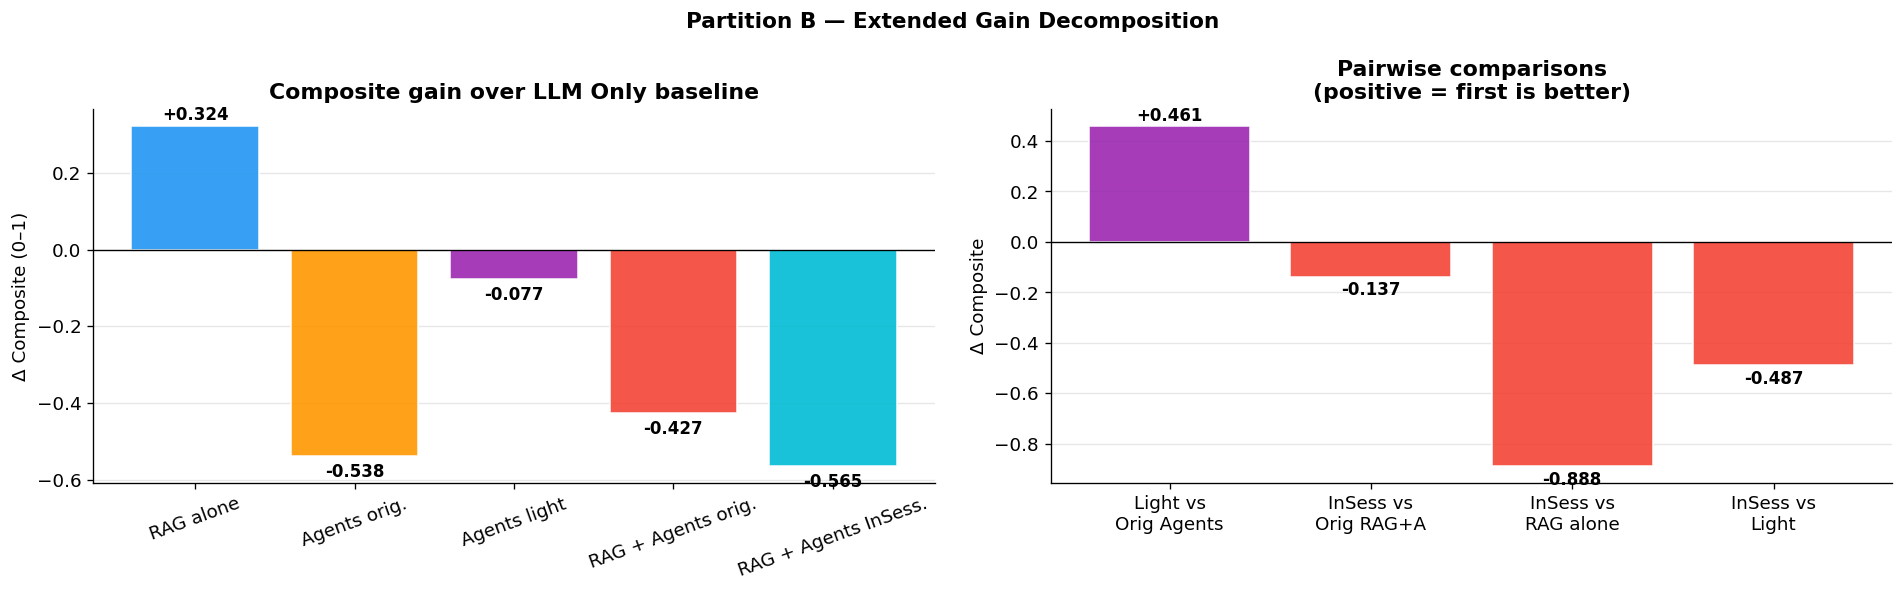

Saved: sys_09b_extended_gains.png


In [13]:
# ── Extended gain decomposition: all components explained ────────────────────
_gain_def = [
    ('rag_gain',        'RAG alone',            '#2196F3'),
    ('agent_gain',      'Agents orig.',          '#FF9800'),
    ('light_gain',      'Agents light',          '#9C27B0'),
    ('full_gain',       'RAG + Agents orig.',    '#F44336'),
    ('insession_gain',  'RAG + Agents InSess.',  '#00BCD4'),
]

_bar_labels = [d[1] for d in _gain_def]
_bar_vals   = [_gains_b.get(d[0], 0) for d in _gain_def]
_bar_clrs   = [d[2] for d in _gain_def]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Partition B — Extended Gain Decomposition', fontsize=13, fontweight='bold')

# ── Left: all gains vs LLM Only ───────────────────────────────────────────────
bars = ax1.bar(_bar_labels, _bar_vals, color=_bar_clrs, edgecolor='white', alpha=0.9)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Composite gain over LLM Only baseline', fontweight='bold')
ax1.set_ylabel('Δ Composite (0–1)')
ax1.tick_params(axis='x', labelrotation=20)
ax1.yaxis.grid(True, alpha=0.3)
ax1.set_axisbelow(True)
for bar, val in zip(bars, _bar_vals):
    ypos = val + 0.005 if val >= 0 else val - 0.018
    ax1.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.3f}',
             ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=10, fontweight='bold')

# ── Right: key pairwise comparisons ──────────────────────────────────────────
_pw_labels = [
    'Light vs\nOrig Agents',
    'InSess vs\nOrig RAG+A',
    'InSess vs\nRAG alone',
    'InSess vs\nLight',
]
_pw_vals = [
    _gains_b.get('light_vs_agents', 0),
    round(_metrics_b.get('LLM + RAG + Agents (In-Session)', {}).get('mean_composite', 0)
          - _metrics_b.get('LLM + RAG + Agents', {}).get('mean_composite', 0), 4),
    _gains_b.get('insession_vs_rag', 0),
    round(_metrics_b.get('LLM + RAG + Agents (In-Session)', {}).get('mean_composite', 0)
          - _metrics_b.get('LLM + Agents (Light)', {}).get('mean_composite', 0), 4),
]
_pw_clrs = ['#9C27B0' if v >= 0 else '#F44336' for v in _pw_vals]
bars2 = ax2.bar(_pw_labels, _pw_vals, color=_pw_clrs, edgecolor='white', alpha=0.9)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Pairwise comparisons\n(positive = first is better)', fontweight='bold')
ax2.set_ylabel('Δ Composite')
ax2.yaxis.grid(True, alpha=0.3)
ax2.set_axisbelow(True)
for bar, val in zip(bars2, _pw_vals):
    ypos = val + 0.005 if val >= 0 else val - 0.018
    ax2.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.3f}',
             ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sys_09b_extended_gains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sys_09b_extended_gains.png')

In [14]:
# ── Final 6-arch ranking table ───────────────────────────────────────────────
_rank_df = pd.DataFrame({
    a: {
        'Composite':    _metrics_b[a]['mean_composite'],
        'Correctness':  _metrics_b[a]['mean_correctness'] / 3,
        'Completeness': _metrics_b[a]['mean_completeness'] / 2,
        'Clarity':      _metrics_b[a]['mean_clarity'] / 2,
        'Good%':        _metrics_b[a]['pct_good'],
        'Excellent%':   _metrics_b[a]['pct_excellent'],
        'Gain vs Base': _metrics_b[a]['mean_composite']
                        - _metrics_b['LLM Only']['mean_composite'],
    }
    for a in ARCH_NAMES_EXTENDED if a in _metrics_b
}).T.sort_values('Composite', ascending=False)

print('\n=== Final Architecture Ranking ===')
display(_rank_df.round(3))

# Highlight best
_best = _rank_df.index[0]
_best_m = _metrics_b[_best]
print(f'\n🥇 Best architecture: {_best}')
print(f'   Composite: {_best_m["mean_composite"]:.3f}  '
      f'Good: {_best_m["pct_good"]*100:.0f}%  '
      f'Excellent: {_best_m["pct_excellent"]*100:.0f}%')

_worst_agent_orig = _metrics_b['LLM + Agents']['mean_composite']
_best_agent = max(
    _metrics_b.get('LLM + Agents (Light)', {}).get('mean_composite', 0),
    _metrics_b.get('LLM + RAG + Agents (In-Session)', {}).get('mean_composite', 0)
)
print(f'\n📊 Original agent collapse:   {_worst_agent_orig:.3f}')
print(f'   After fix (max recovered): {_best_agent:.3f}')
print(f'   Recovery:                 +{_best_agent - _worst_agent_orig:.3f}')


=== Final Architecture Ranking ===


,Composite,Correctness,Completeness,Clarity,Good%,Excellent%,Gain vs Base
LLM + RAG,0.947,0.941,0.941,0.971,0.941,0.941,0.324
LLM Only,0.624,0.588,0.647,0.676,0.471,0.412,0.000
LLM + Agents (Light),0.546,0.451,0.500,0.853,0.353,0.235,-0.077
LLM + RAG + Agents,0.196,0.157,0.176,0.324,0.059,0.000,-0.427
LLM + Agents,0.085,0.059,0.088,0.147,0.000,0.000,-0.538
LLM + RAG + Agents (In-Session),0.059,0.059,0.059,0.059,0.059,0.059,-0.565



🥇 Best architecture: LLM + RAG
   Composite: 0.947  Good: 94%  Excellent: 94%

📊 Original agent collapse:   0.085
   After fix (max recovered): 0.546
   Recovery:                 +0.461


## Summary & Interpretation

### Reading the results

| Result pattern | Interpretation |
|---|---|
| `full_gain >> 0` | Full pipeline is best — integrate both RAG and agents |
| `rag_gain > agent_gain` | RAG contributes more — prioritise Qdrant index quality |
| `agent_gain > rag_gain` | Agent prompts dominate — improve prompts / level tuning |
| `synergy > 0` | Superadditive — agents use retrieved context better than naive LLM |
| `synergy < 0` | Interference — agent prompt conflicts with injected context |

### Decision guide

```
If full_gain ≥ 0.10 → both RAG and multi-agents proven, keep full pipeline
If rag_gain < 0.05  → check Qdrant index coverage / chunk quality
If agent_gain < 0.05→ review LEVEL_GUIDANCE and QA_SYSTEM_PROMPT specificity
If synergy < 0      → reduce context window size or improve chunk trimming
```

### Charts saved

| File | Content |
|---|---|
| `sys_01_comparison.png` | 6-panel grouped bar chart |
| `sys_02_heatmap.png` | Performance heatmap |
| `sys_03_distribution.png` | Composite score distributions (violin) |
| `sys_04_radar.png` | Radar chart (3 dimensions) |
| `sys_05_perquestion_heatmap.png` | Per-question composite matrix |
| `sys_06_gain_decomposition.png` | Gain decomposition + stacked bars |
| `sys_07_level_sensitivity.png` | Level comparison (requires `LEVEL=all`) |

In [ ]:
import json as _json
_out = {
    'discipline': DISCIPLINE,
    'top_k': TOP_K,
    'questions': questions,
    'levels': {
        lv: {'metrics': _all_metrics[lv], 'gains': _all_gains[lv]}
        for lv in _levels
    }
}
_json_path = 'system_bench_results.json'
Path(_json_path).write_text(_json.dumps(_out, ensure_ascii=False, indent=2), 'utf-8')
print(f'Results saved → {_json_path}')

# Quick summary table
df_summary = pd.DataFrame({
    a: {'Composite': metrics[a]['mean_composite'],
        'Good%':  f"{metrics[a]['pct_good']*100:.0f}%",
        'Excel%': f"{metrics[a]['pct_excellent']*100:.0f}%",
        'Gain vs LLM Only': f'{metrics[a]["mean_composite"] - metrics["LLM Only"]["mean_composite"]:+.3f}'}
    for a in ARCH_NAMES
}).T
print('\n=== Final Summary ===')
display(df_summary)